# Capítulos 4 y 5: Flujo, sistemas lineales y Hartman–Grobman

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/03-lineales-HG.ipynb)

Notebook que acompaña a los Capítulos 4 y 5 de *Introducción al Modelado Continuo*. Reproduce las figuras de los dos capítulos (los retratos de fase de los sistemas lineales planos, el plano traza–determinante, el péndulo amortiguado y el oscilador perturbado) y usa la linealización para justificar numéricamente lo que en el Capítulo 2 sólo se observó en las simulaciones.

Las herramientas son las de estos capítulos: la exponencial de una matriz, autovalores, traza y determinante, la clasificación de los sistemas lineales planos y el Teorema de Hartman–Grobman. Cada figura de las notas sale de una celda marcada con su nombre de archivo.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from imc import estilo, fases
from imc.estilo import COLORES, CICLO

estilo.activar()
plt.close(plt.figure())   # inicializa el backend inline fuera de los rc_context de abajo (si no, las figuras no se muestran)
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/

def fuente(F):
    # contexto con fuente F: las figuras se incluyen chicas en las notas y la letra tiene que seguir legible
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})

## 5.2 Sistemas lineales en el plano

Para $\dot{\mathbf x} = A\mathbf x$ la solución es $\mathbf x(t) = e^{tA}\mathbf x_0$, y el comportamiento del origen lo deciden los autovalores de $A$. En dimensión dos alcanza con la traza y el determinante, porque $p_A(\lambda) = \lambda^2 - \operatorname{tr}(A)\lambda + \det(A)$.

La función `retrato_lineal` dibuja el campo de direcciones y algunas trayectorias de $\dot{\mathbf x} = A\mathbf x$ en el cuadrado $[-3,3]^2$, y escribe la matriz y sus autovalores en un recuadro. Como el sistema es lineal, el campo `lineal` sirve tanto para `solve_ivp` (un punto) como para el campo de direcciones (una grilla).

**Figura `silla`**: $\det A<0$, autovalores reales de distinto signo. Los ejes son las direcciones estable ($y$) e inestable ($x$).

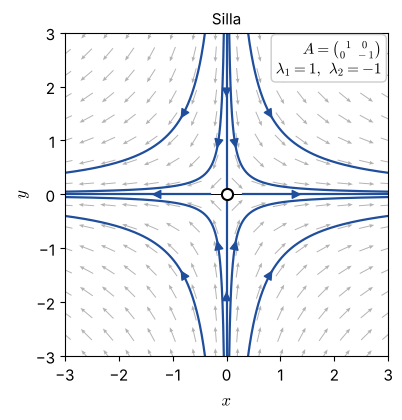

In [2]:
def lineal(t, X, A):
    # campo lineal X' = A X; funciona sobre un punto o sobre una grilla
    return np.einsum("ij,j...->i...", A, np.asarray(X, dtype=float))

def texto_matriz(A):
    a, b, c, d = (f"{v:g}" for v in np.ravel(A))
    return rf"$A = \genfrac{{(}}{{)}}{{0}}{{}}{{{a}\ \ \ {b}}}{{{c}\ \ \ {d}}}$"

def texto_autovalores(A):
    l1, l2 = np.linalg.eigvals(A)
    if abs(l1.imag) > 1e-12:
        re = f"{l1.real:g}" if l1.real != 0 else ""
        im = f"{abs(l1.imag):g}" if abs(l1.imag) != 1 else ""
        return rf"$\lambda = {re} \pm {im}\,i$"
    return rf"$\lambda_1 = {l1.real:g},\ \lambda_2 = {l2.real:g}$"

def retrato_lineal(A, inicios, T, titulo, nombre, tipo="inestable", pos_flecha=0.4, loc="lower right", L=3):
    A = np.array(A, dtype=float)
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    fases.campo(lineal, (-L, L), (-L, L), ax=ax, n=16, args=(A,))
    pos = np.resize(pos_flecha, len(inicios))          # una posición de flecha por trayectoria
    for X0, q in zip(inicios, pos):
        fases.trayectoria(lineal, X0, T, ax=ax, args=(A,), pos_flecha=q)
    fases.marcar_equilibrios(ax, [(0, 0, tipo)])
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    ax.axhline(0, color="black", lw=0.7, zorder=0); ax.axvline(0, color="black", lw=0.7, zorder=0)
    ax.set_title(titulo, fontsize=11); ax.set_aspect("equal")
    ax.xaxis.label.set_size(12); ax.yaxis.label.set_size(12); ax.tick_params(labelsize=11)
    estilo.parametros(ax, texto_matriz(A) + "\n" + texto_autovalores(A), loc=loc, fontsize=11)
    if GUARDAR: estilo.guardar(fig, nombre)
    return fig

A_silla = [[1, 0], [0, -1]]
inicios = [(sx * 0.05, sy * 3) for sx in (1, -1) for sy in (1, -1)] + \
          [(sx * 0.4, sy * 3) for sx in (1, -1) for sy in (1, -1)] + [(0, 3), (0, -3), (0.3, 0), (-0.3, 0)]
retrato_lineal(A_silla, inicios, np.log(60), "Silla", "silla", tipo="silla", loc="upper right");

**Figuras `nodo1` y `nodo2`**: $\det A>0$ y $\operatorname{tr}(A)^2 > 4\det A$, autovalores reales del mismo signo. Con $A$ diagonal las trayectorias son las curvas $y = c\,x^{\lambda_2/\lambda_1}$: parábolas para $\lambda_2 = 2\lambda_1$ (nodo inestable, `nodo1`) y raíces cuadradas para $\lambda_2 = \lambda_1/2$ (nodo estable, `nodo2`). Todas las trayectorias, salvo las del eje $y$, entran al origen tangentes al eje del autovalor de menor módulo.

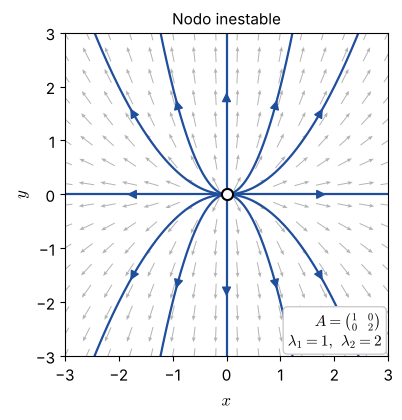

In [3]:
A_nodo1 = [[1, 0], [0, 2]]
# parábolas y = c x^2: arrancan en (x0, c x0^2) con x0 chico
inicios = [(sx * 0.1, c * 0.01) for c in (0.5, 2, -0.5, -2) for sx in (1, -1)] + [(0, 0.1), (0, -0.1), (0.1, 0), (-0.1, 0)]
retrato_lineal(A_nodo1, inicios, np.log(30), "Nodo inestable", "nodo1", pos_flecha=0.6);

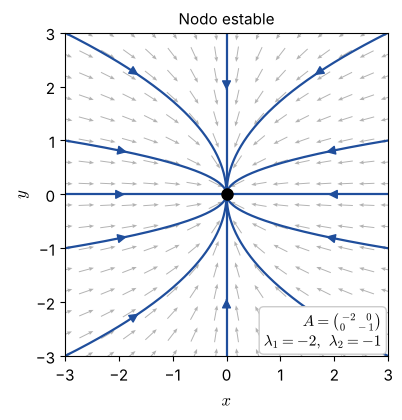

In [4]:
A_nodo2 = [[-2, 0], [0, -1]]
inicios = [(3, 3), (3, -3), (-3, 3), (-3, -3), (3, 1), (3, -1), (-3, 1), (-3, -1), (0, 3), (0, -3), (3, 0), (-3, 0)]
retrato_lineal(A_nodo2, inicios, np.log(60), "Nodo estable", "nodo2", tipo="estable", pos_flecha=0.35);

**Figuras `foco1` y `foco2`**: $\det A>0$ y $\operatorname{tr}(A)^2 < 4\det A$, autovalores complejos conjugados $\alpha\pm i\beta$. Para $A = \begin{pmatrix}\alpha & -\beta\\ \beta & \alpha\end{pmatrix}$ la solución es $e^{\alpha t}$ por una rotación de ángulo $\beta t$: espirales que se abren si $\alpha>0$ (foco inestable) y se cierran si $\alpha<0$ (foco estable).

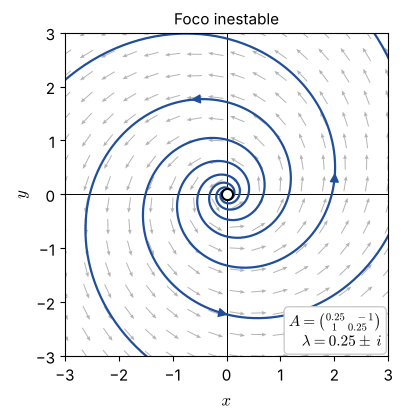

In [5]:
A_foco1 = [[0.25, -1], [1, 0.25]]
inicios = [(0.05 * np.cos(a), 0.05 * np.sin(a)) for a in (0, 2 * np.pi / 3, 4 * np.pi / 3)]
retrato_lineal(A_foco1, inicios, np.log(90) / 0.25, "Foco inestable", "foco1", pos_flecha=0.55);

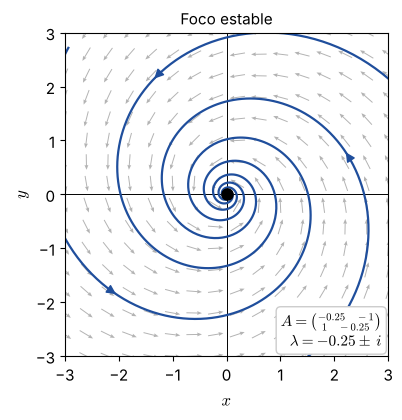

In [6]:
A_foco2 = [[-0.25, -1], [1, -0.25]]
inicios = [(4 * np.cos(a), 4 * np.sin(a)) for a in (0.3, 0.3 + 2 * np.pi / 3, 0.3 + 4 * np.pi / 3)]
retrato_lineal(A_foco2, inicios, np.log(80) / 0.25, "Foco estable", "foco2", tipo="estable", pos_flecha=0.3);

**Figura `centro`**: $\det A>0$ y $\operatorname{tr} A = 0$, autovalores $\pm i\sqrt{\det A}$. Las trayectorias son órbitas cerradas: para $A = \begin{pmatrix}0 & -2\\ 1/2 & 0\end{pmatrix}$ la cantidad $x^2/4 + y^2$ se conserva y las órbitas son elipses (un centro no tiene por qué dar círculos). El equilibrio es estable pero no asintóticamente estable.

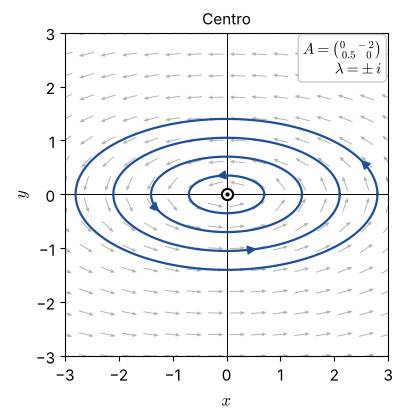

In [7]:
A_centro = [[0, -2], [0.5, 0]]
inicios = [(x0, 0) for x0 in (0.7, 1.4, 2.1, 2.8)]
retrato_lineal(A_centro, inicios, 2 * np.pi, "Centro", "centro", tipo="centro", pos_flecha=[0.3, 0.55, 0.8, 0.05], loc="upper right");

### Traza, determinante y tipo

`fases.clasificar` implementa el teorema de clasificación de las notas leyendo sólo la traza y el determinante. Verificamos que coincide con los autovalores en las seis matrices de las figuras.

In [8]:
matrices = {"silla": A_silla, "nodo1": A_nodo1, "nodo2": A_nodo2, "foco1": A_foco1, "foco2": A_foco2, "centro": A_centro}
print(f"{'figura':8s} {'tr A':>6s} {'det A':>7s} {'tr^2-4det':>10s}  {'tipo (fases.clasificar)':24s} autovalores")
for nombre, A in matrices.items():
    A = np.array(A, dtype=float)
    tr, det = np.trace(A), np.linalg.det(A)
    print(f"{nombre:8s} {tr:6.2f} {det:7.3f} {tr**2 - 4 * det:10.3f}  {fases.clasificar(A):24s} {np.round(np.linalg.eigvals(A), 3)}")

figura     tr A   det A  tr^2-4det  tipo (fases.clasificar)  autovalores
silla      0.00  -1.000      4.000  silla                    [ 1.+0.j -1.+0.j]
nodo1      3.00   2.000      1.000  nodo inestable           [1.+0.j 2.+0.j]
nodo2     -3.00   2.000      1.000  nodo estable             [-2.+0.j -1.+0.j]
foco1      0.50   1.062     -4.000  foco inestable           [0.25+1.j 0.25-1.j]
foco2     -0.50   1.062     -4.000  foco estable             [-0.25+1.j -0.25-1.j]
centro     0.00   1.000     -4.000  centro                   [0.+1.j 0.-1.j]


**Figura `clasificacion`**: las regiones del plano $(\operatorname{tr}A, \det A)$ del teorema de clasificación. La parábola $\det A = \operatorname{tr}(A)^2/4$ separa autovalores reales (nodos, abajo) de complejos (focos, arriba); el semiplano $\det A<0$ es el de las sillas y la semirrecta $\operatorname{tr}A = 0$, $\det A>0$, la de los centros. Los puntos son las seis matrices de las figuras anteriores.

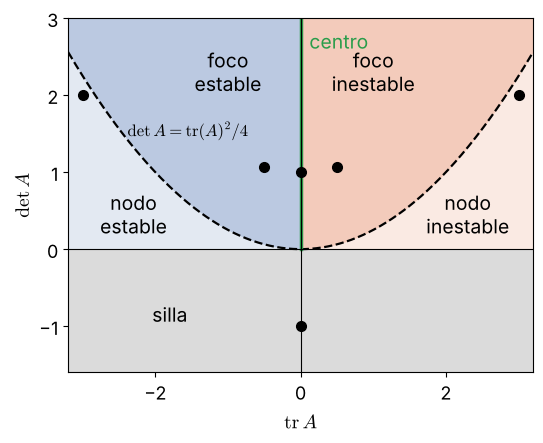

In [9]:
F = 14
with fuente(F):
    fig, ax = plt.subplots(figsize=(6, 4.6))
    tr = np.linspace(-3.2, 3.2, 400); par = tr**2 / 4
    top, bot = 3.0, -1.6
    ax.fill_between(tr, par, top, where=tr < 0, color=COLORES["traj"], alpha=0.30, lw=0)
    ax.fill_between(tr, 0, par, where=tr < 0, color=COLORES["traj"], alpha=0.12, lw=0)
    ax.fill_between(tr, par, top, where=tr > 0, color=COLORES["nul_h"], alpha=0.30, lw=0)
    ax.fill_between(tr, 0, par, where=tr > 0, color=COLORES["nul_h"], alpha=0.12, lw=0)
    ax.fill_between(tr, bot, 0, color="0.6", alpha=0.35, lw=0)
    ax.plot(tr, par, "k--", lw=1.6)
    ax.plot([0, 0], [0, top], color=COLORES["nul_p"], lw=2.5)
    ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
    ax.text(-1.0, 2.3, "foco\nestable", ha="center", va="center")
    ax.text(1.0, 2.3, "foco\ninestable", ha="center", va="center")
    ax.text(-2.3, 0.45, "nodo\nestable", ha="center", va="center")
    ax.text(2.3, 0.45, "nodo\ninestable", ha="center", va="center")
    ax.text(-1.8, -0.85, "silla", ha="center", va="center")
    ax.text(0.12, 2.85, "centro", color=COLORES["nul_p"], ha="left", va="top")
    ax.text(-1.55, 1.4, r"$\det A = \mathrm{tr}(A)^2/4$", ha="center", va="bottom", fontsize=F - 2)
    for nombre, A in matrices.items():
        A = np.array(A, dtype=float)
        ax.plot(np.trace(A), np.linalg.det(A), "o", color="black", ms=7, zorder=5)
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(bot, top)
    ax.set_xlabel(r"$\mathrm{tr}\,A$"); ax.set_ylabel(r"$\det A$")
    ax.set_xticks([-2, 0, 2]); ax.set_yticks([-1, 0, 1, 2, 3])
    if GUARDAR: estilo.guardar(fig, "clasificacion")

## 5.3 Hartman–Grobman: el péndulo amortiguado

$$\ddot\theta + 2a\dot\theta + \omega^2\sin\theta = 0
\qquad\Longleftrightarrow\qquad
\dot x_1 = x_2,\quad \dot x_2 = -2a\,x_2 - \omega^2\sin x_1,$$
con $x_1 = \theta$ y $x_2 = \dot\theta$. Equilibrios $(k\pi, 0)$: para $k$ par la linealización tiene autovalores $-a\pm\sqrt{a^2-\omega^2}$ (foco estable si $\omega>a$, nodo estable si $\omega\le a$), para $k$ impar $-a\pm\sqrt{a^2+\omega^2}$ (silla). Todos son hiperbólicos, así que cerca de cada uno el diagrama de fases se ve como el del sistema lineal.

**Figura `pendulo-amortiguado`**: caso $\omega>a$. Las curvas que salen de las sillas son sus variedades estable e inestable (las separatrices): se obtienen integrando hacia adelante y hacia atrás desde un punto a distancia $\varepsilon$ de la silla en la dirección del autovector correspondiente.

equilibrio (0.000, 0): foco estable   autovalores [-0.15+0.9887j -0.15-0.9887j]  fórmula [-0.15+0.9887j -0.15-0.9887j]
equilibrio (3.142, 0): silla          autovalores [ 0.8612+0.j -1.1612+0.j]  fórmula [ 0.8612+0.j -1.1612+0.j]


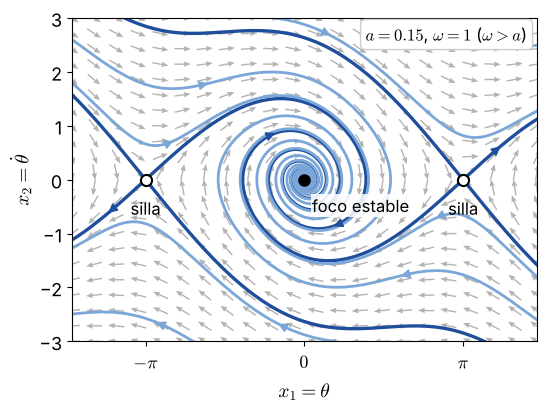

In [10]:
def pendulo_amortiguado(t, X, a, w):
    th, v = X
    return [v, -2 * a * v - w**2 * np.sin(th)]

a, w = 0.15, 1.0
for th_e in (0.0, np.pi):
    J = fases.jacobiano(pendulo_amortiguado, [th_e, 0.0], args=(a, w))
    formula = -a + np.array([1, -1]) * np.sqrt(a**2 - w**2 * np.cos(th_e) + 0j)
    print(f"equilibrio ({th_e:.3f}, 0): {fases.clasificar(J):14s} autovalores {np.round(np.linalg.eigvals(J), 4)}  fórmula {np.round(formula, 4)}")

F = 14
with fuente(F):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    L, V = 4.6, 3.0
    fases.campo(pendulo_amortiguado, (-L, L), (-V, V), ax=ax, n=22, args=(a, w))
    # separatrices de las sillas (+-pi, 0): autovectores de la linealización
    eps = 1e-3
    for s in (np.pi, -np.pi):
        J = fases.jacobiano(pendulo_amortiguado, [s, 0.0], args=(a, w))
        lam, vec = np.linalg.eig(J)
        for j in range(2):
            for signo in (1, -1):
                X0 = np.array([s, 0.0]) + signo * eps * vec[:, j].real
                if lam[j].real > 0:   # rama inestable: hacia adelante
                    fases.trayectoria(pendulo_amortiguado, X0, 60, ax=ax, args=(a, w), pos_flecha=0.5, lw=2.4)
                else:                 # rama estable: hacia atrás
                    fases.trayectoria(pendulo_amortiguado, X0, 1e-3, ax=ax, args=(a, w), flecha=False, atras=True, T_atras=14, lw=2.4)
    # trayectorias genéricas
    for X0 in [(-L, 2.6), (-L, 1.8), (L, -2.6), (L, -1.8), (-0.6, 3), (0.6, -3), (2.2, 3), (-2.2, -3)]:
        fases.trayectoria(pendulo_amortiguado, X0, 60, ax=ax, args=(a, w), color=COLORES["traj2"], pos_flecha=0.15)
    fases.marcar_equilibrios(ax, [(0, 0, "estable"), (np.pi, 0, "silla"), (-np.pi, 0, "silla")])
    ax.text(0.15, -0.3, "foco estable", ha="left", va="top", fontsize=F - 2, bbox=dict(fc="white", ec="none", alpha=0.85, pad=1))
    ax.text(np.pi, -0.35, "silla", ha="center", va="top", fontsize=F - 2); ax.text(-np.pi, -0.35, "silla", ha="center", va="top", fontsize=F - 2)
    ax.set_xlim(-L, L); ax.set_ylim(-V, V)
    ax.set_xticks([-np.pi, 0, np.pi]); ax.set_xticklabels([r"$-\pi$", "$0$", r"$\pi$"])
    ax.set_xlabel(r"$x_1 = \theta$"); ax.set_ylabel(r"$x_2 = \dot\theta$")
    estilo.parametros(ax, rf"$a = {a}$, $\omega = {w:g}$ ($\omega > a$)", loc="upper right", fontsize=F - 2)
    if GUARDAR: estilo.guardar(fig, "pendulo-amortiguado")

### Cuando la linealización no decide: el oscilador armónico perturbado

$$\dot x = y + \lambda x(x^2+y^2),\qquad \dot y = -x + \lambda y(x^2+y^2).$$

La linealización en el origen es la del oscilador armónico, con autovalores $\pm i$, para *todo* $\lambda$: el origen no es hiperbólico y Hartman–Grobman no se aplica. En polares, $\dot r = \lambda r^3$ y $\dot\theta = -1$: el origen es asintóticamente estable si $\lambda<0$, un centro si $\lambda = 0$ e inestable si $\lambda>0$. La ecuación de $r$ se integra a mano, $r(t)^{-2} = r_0^{-2} - 2\lambda t$, lo que nos da el tiempo exacto que tarda cada trayectoria en ir de un radio a otro (y muestra que para $\lambda>0$ las soluciones explotan en tiempo finito).

**Figura `sinHG`**: a la izquierda $\lambda>0$, a la derecha $\lambda<0$.

max |r^-2 - (r0^-2 - 2 lam t)| = 2.6604629610460506e-10


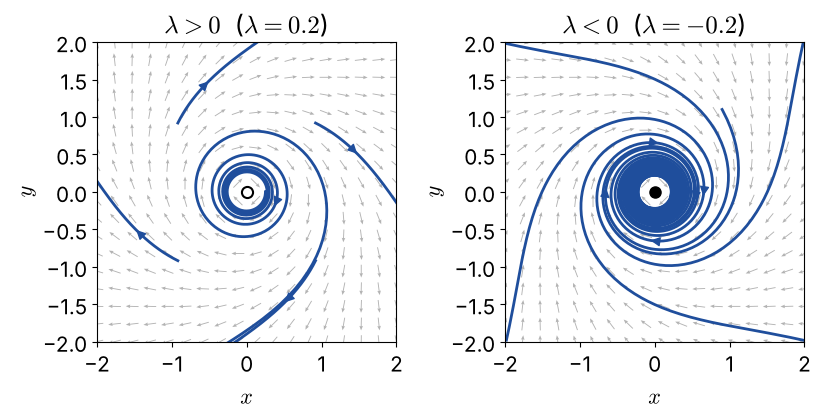

In [11]:
def oscilador_perturbado(t, X, lam):
    x, y = X
    r2 = x**2 + y**2
    return [y + lam * x * r2, -x + lam * y * r2]

def tiempo_radial(r0, r1, lam):
    # tiempo que tarda r en ir de r0 a r1 según r' = lam r^3
    return (1 / r0**2 - 1 / r1**2) / (2 * lam)

# comprobación: r(t)^-2 = r0^-2 - 2 lam t a lo largo de una solución numérica
lam0, X0 = 0.2, [0.5, 0.0]
sol = solve_ivp(oscilador_perturbado, (0, 5), X0, args=(lam0,), rtol=1e-10, atol=1e-12, dense_output=True)
tt = np.linspace(0, 5, 6); r = np.hypot(*sol.sol(tt))
print("max |r^-2 - (r0^-2 - 2 lam t)| =", np.abs(r**-2 - (1 / 0.5**2 - 2 * lam0 * tt)).max())

F = 16
with fuente(F):
    fig, axs = plt.subplots(1, 2, figsize=(8.4, 4.2))
    L = 2.0
    for ax, lam in zip(axs, (0.2, -0.2)):
        fases.campo(oscilador_perturbado, (-L, L), (-L, L), ax=ax, n=18, args=(lam,))
        if lam > 0:   # salen desde cerca del origen hasta abandonar el cuadrado
            inicios = [(0.25, 0.0)] + [(1.3 * np.cos(a), 1.3 * np.sin(a)) for a in np.pi / 4 + np.arange(4) * np.pi / 2]
            for X0 in inicios:
                T = tiempo_radial(np.hypot(*X0), 3.0, lam)
                fases.trayectoria(oscilador_perturbado, X0, T, ax=ax, args=(lam,), pos_flecha=0.45)
            ax.set_title(r"$\lambda > 0$" + rf"  ($\lambda = {lam}$)", fontsize=F + 2)
        else:         # entran desde afuera y se acumulan en el origen
            inicios = [(2.8 * np.cos(a), 2.8 * np.sin(a)) for a in np.pi / 4 + np.arange(4) * np.pi / 2] + [(0.9, 1.1)]
            for X0 in inicios:
                T = tiempo_radial(np.hypot(*X0), 0.22, lam)
                fases.trayectoria(oscilador_perturbado, X0, T, ax=ax, args=(lam,), pos_flecha=0.3)
            ax.set_title(r"$\lambda < 0$" + rf"  ($\lambda = {lam}$)", fontsize=F + 2)
        fases.marcar_equilibrios(ax, [(0, 0, "estable" if lam < 0 else "inestable")])
        ax.set_xlim(-L, L); ax.set_ylim(-L, L); ax.set_aspect("equal")
        ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "sinHG")

### Una conjugación explícita (y por qué es sólo topológica)

La observación que sigue al enunciado del teorema compara $\dot x = x,\ \dot y = 2y$ con $\dot x = x,\ \dot y = 2y + x^2$: misma linealización en el origen, pero ningún cambio de coordenadas $C^2$ conjuga sus flujos (resonancia $\lambda_2 = 2\lambda_1$). La conjugación existe, y es explícita: $\mathbf h(x,y) = (x,\ y - x^2\ln|x|)$, que es $C^1$ pero no $C^2$ en $x=0$. Resolviendo a mano, $x(t) = x_0e^t$ y $y(t) = (y_0 + x_0^2 t)e^{2t}$, y se comprueba que $\mathbf h\circ\phi_t = \psi_t\circ\mathbf h$.

**Figura nueva `flujo-conjugacion`**: los dos retratos de fase, con las mismas condiciones iniciales. Se ven "iguales" cerca del origen (los dos son nodos inestables), aunque las trayectorias del no lineal no son parábolas.

max |h(phi_t(X)) - psi_t(h(X))| y error de la fórmula de phi: 4.6e-10


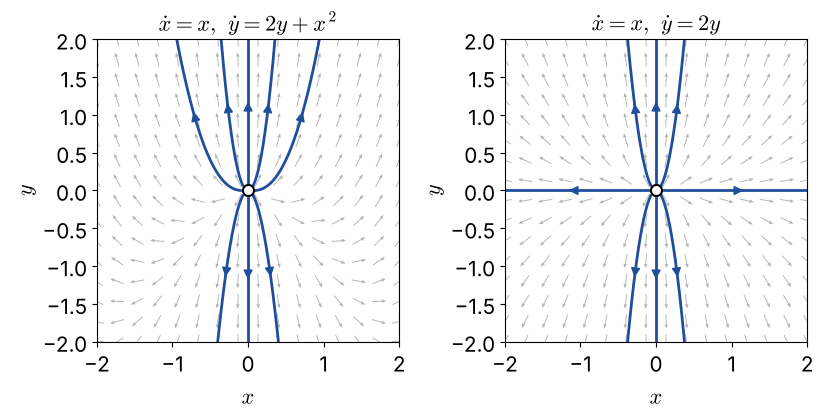

In [12]:
F_lin = lambda t, X: [X[0], 2 * X[1]]
F_nl = lambda t, X: [X[0], 2 * X[1] + X[0]**2]
h = lambda x, y: (x, y - x**2 * np.log(np.abs(x)))
phi = lambda t, x0, y0: (x0 * np.exp(t), (y0 + x0**2 * t) * np.exp(2 * t))     # flujo del no lineal
psi = lambda t, x0, y0: (x0 * np.exp(t), y0 * np.exp(2 * t))                   # flujo del lineal

# verificación numérica de h(phi_t(X)) = psi_t(h(X)) y de la fórmula de phi
err = 0.0
for (x0, y0) in [(0.5, 0.3), (-0.8, 0.1), (0.2, -0.7)]:
    for t in (0.5, 1.0, 2.0):
        num = solve_ivp(F_nl, (0, t), [x0, y0], rtol=1e-11, atol=1e-13).y[:, -1]
        err = max(err, np.abs(np.array(phi(t, x0, y0)) - num).max(),
                  np.abs(np.array(h(*phi(t, x0, y0))) - np.array(psi(t, *h(x0, y0)))).max())
print("max |h(phi_t(X)) - psi_t(h(X))| y error de la fórmula de phi:", f"{err:.1e}")

F = 16
with fuente(F):
    fig, axs = plt.subplots(1, 2, figsize=(8.4, 4.2))
    L = 2.0
    inicios = [(0.1 * np.cos(a), 0.1 * np.sin(a)) for a in np.arange(8) * np.pi / 4]
    for ax, campo_, titulo in zip(axs, (F_nl, F_lin), (r"$\dot x = x,\ \dot y = 2y + x^2$", r"$\dot x = x,\ \dot y = 2y$")):
        fases.retrato(campo_, (-L, L), (-L, L), inicios, np.log(30), ax=ax, n_campo=16,
                      equilibrios=[(0, 0, "inestable")], xlabel="$x$", ylabel="$y$", pos_flecha=0.55)
        ax.set_aspect("equal"); ax.set_title(titulo)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "flujo-conjugacion")

## 5.4 Volvemos a los modelos poblacionales

La receta: matriz diferencial en cada equilibrio, traza y determinante (o autovalores), verificar hiperbolicidad y leer el teorema de clasificación. Para Lotka–Volterra con capacidad de carga,
$$h' = \rho h\Bigl(1-\frac hk - p\Bigr),\qquad p' = -\frac1\rho\,p(1-h),\qquad
DF\Bigl(1, 1-\tfrac1k\Bigr) = \begin{pmatrix} -\rho/k & -\rho\\ \frac{k-1}{k\rho} & 0\end{pmatrix},\qquad
\lambda_\pm = \frac{-\rho\pm\sqrt{\rho^2 - 4k(k-1)}}{2k}.$$

**Figura nueva `linealizacion-LV2`**: Hartman–Grobman "en vivo". A la izquierda el sistema no lineal en una ventana alrededor del equilibrio de coexistencia; a la derecha el sistema linealizado $\dot{\mathbf y} = DF(\mathbf x^*)\mathbf y$ dibujado en las mismas coordenadas ($\mathbf x = \mathbf x^* + \mathbf y$) y con las mismas condiciones iniciales. Arriba el caso nodo ($\rho^2 \ge 4k(k-1)$), abajo el caso foco.

rho = 2.0, k = 1.3: nodo estable  autovalores [-1.37  +0.j -0.1684+0.j]  fórmula [-0.1684+0.j -1.37  +0.j]


rho = 1.0, k = 2.0: foco estable  autovalores [-0.25+0.6614j -0.25-0.6614j]  fórmula [-0.25+0.6614j -0.25-0.6614j]


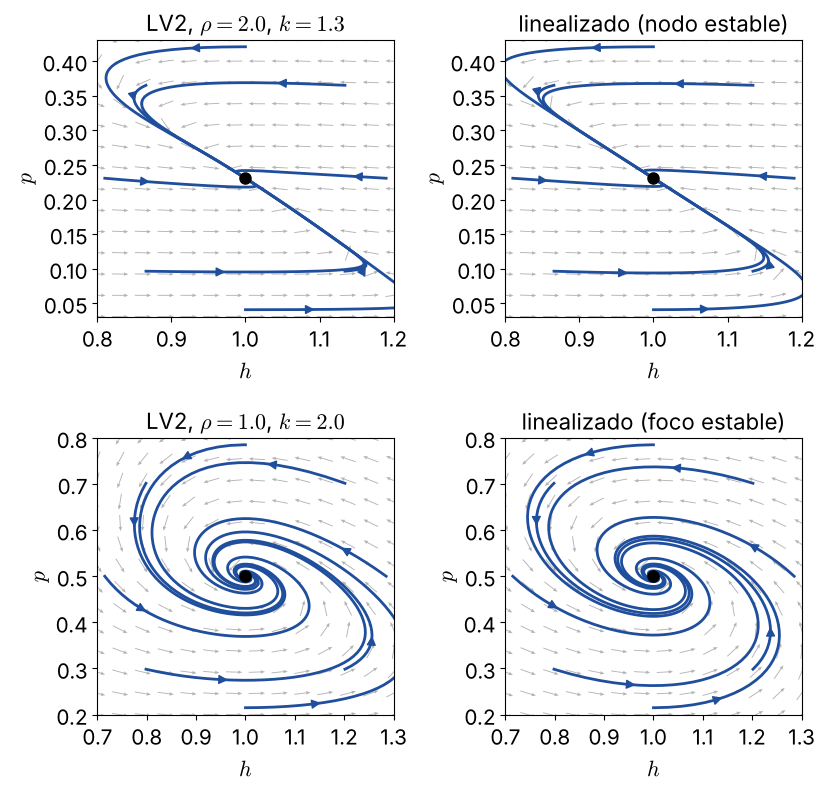

In [13]:
def LV2(t, X, rho, k):
    h, p = X
    return [rho * h * (1 - h / k - p), -p * (1 - h) / rho]

def linealizado(F, Xe, args=()):
    # campo lineal y' = DF(Xe) y, escrito en las coordenadas originales x = Xe + y
    J = fases.jacobiano(F, Xe, args)
    Xe = np.asarray(Xe, dtype=float)
    def G(t, X):
        Y = np.asarray(X, dtype=float) - Xe.reshape((2,) + (1,) * (np.ndim(X) - 1))
        return np.einsum("ij,j...->i...", J, Y)
    return G, J

F = 16
with fuente(F):
    fig, axs = plt.subplots(2, 2, figsize=(8.4, 8.2))
    for fila, (rho, k, d) in zip(axs, [(2.0, 1.3, 0.2), (1.0, 2.0, 0.3)]):
        Xe = np.array([1.0, 1 - 1 / k])
        G, J = linealizado(LV2, Xe, (rho, k))
        lam_teo = (-rho + np.array([1, -1]) * np.sqrt(rho**2 - 4 * k * (k - 1) + 0j)) / (2 * k)
        print(f"rho = {rho}, k = {k}: {fases.clasificar(J):13s} autovalores {np.round(np.linalg.eigvals(J), 4)}  fórmula {np.round(lam_teo, 4)}")
        hl, pl = (Xe[0] - d, Xe[0] + d), (Xe[1] - d, Xe[1] + d)
        inicios = [Xe + 0.95 * d * np.array([np.cos(a), np.sin(a)]) for a in np.arange(8) * np.pi / 4]
        for ax, campo_, args, titulo in zip(fila, (LV2, G), ((rho, k), ()), ("", "")):
            fases.retrato(campo_, hl, pl, inicios, 40, ax=ax, args=args, n_campo=14,
                          equilibrios=[(Xe[0], Xe[1], "estable")], xlabel="$h$", ylabel="$p$", pos_flecha=0.12)
            ax.set_title(titulo)
        fila[0].set_title(rf"LV2, $\rho = {rho}$, $k = {k}$")
        fila[1].set_title(f"linealizado ({fases.clasificar(J)})")
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "linealizacion-LV2")

### Verificación de las matrices diferenciales de la Sección 5.4

Comparamos, para cada modelo del Capítulo 2, los autovalores de la matriz diferencial calculada numéricamente (`fases.jacobiano`, diferencias centradas) con las fórmulas cerradas del texto. Para el modelo de bacterias comparamos además la matriz completa con la que da el texto.

In [14]:
def LV1(t, X, rho):
    h, p = X
    return [rho * h * (1 - p), -p * (1 - h) / rho]

def bacterias(t, X, k, beta, gamma):
    h, p = X
    ah, ap = (1 - 1 / k) * (beta + 1), gamma * (beta + 1)
    return [h * (1 - h / k) - ah * p * h / (beta + h), ap * p * h / (beta + h) - gamma * p]

def SIR(t, X, beta, gamma):
    s, i = X
    return [-beta * s * i, beta * s * i - gamma * i]

def vdP(t, X, lam):
    x, y = X
    return [y, -x - lam * (x**2 - 1) * y]

def comparar(nombre, F, Xe, args, formula):
    J = fases.jacobiano(F, Xe, args)
    num = np.sort_complex(np.linalg.eigvals(J).astype(complex))
    teo = np.sort_complex(np.array(formula, dtype=complex))
    print(f"{nombre:34s} {fases.clasificar(J):14s} numérico {np.round(num, 4)}  fórmula {np.round(teo, 4)}  |dif| = {np.abs(num - teo).max():.0e}")
    return J

raiz = lambda z: np.sqrt(z + 0j)
rho = 1.5
comparar("LV1 en (0,0)", LV1, [0, 0], (rho,), [rho, -1 / rho])
comparar("LV1 en (1,1)  [no hiperbólico]", LV1, [1, 1], (rho,), [1j, -1j])
for rho, k in [(1.0, 0.5), (1.0, 2.0)]:
    comparar(f"LV2 en (k,0), rho={rho}, k={k}", LV2, [k, 0], (rho, k), [-rho, (k - 1) / rho])
for rho, k in [(2.0, 1.3), (1.0, 2.0)]:
    comparar(f"LV2 en (1,1-1/k), rho={rho}, k={k}", LV2, [1, 1 - 1 / k], (rho, k),
             (-rho + np.array([1, -1]) * raiz(rho**2 - 4 * k * (k - 1))) / (2 * k))
beta, gamma = 1.0, 0.5
for k in (2.5, 4.0):
    J_texto = np.array([[(k - 2 - beta) / (k * (1 + beta)), -1 + 1 / k], [beta * gamma / (1 + beta), 0]])
    J = comparar(f"bacterias en (1,1), k={k} (k_c={2 + beta})", bacterias, [1, 1], (k, beta, gamma), np.linalg.eigvals(J_texto))
    print(f"{'':34s} |DF numérica - DF del texto| = {np.abs(J - J_texto).max():.0e}")
beta, gamma = 0.6, 0.1
for s in (0.1, 0.5):
    comparar(f"SIR en (s,0), s={s}, 1/R0={gamma / beta:.3f}", SIR, [s, 0], (beta, gamma), [0, beta * s - gamma])
for lam in (0.5, 3.0):
    comparar(f"van der Pol en (0,0), lambda={lam}", vdP, [0, 0], (lam,), (lam + np.array([1, -1]) * raiz(lam**2 - 4)) / 2)

LV1 en (0,0)                       silla          numérico [-0.6667+0.j  1.5   +0.j]  fórmula [-0.6667+0.j  1.5   +0.j]  |dif| = 0e+00
LV1 en (1,1)  [no hiperbólico]     centro         numérico [0.-1.j 0.+1.j]  fórmula [-0.-1.j  0.+1.j]  |dif| = 3e-11
LV2 en (k,0), rho=1.0, k=0.5       nodo estable   numérico [-1. +0.j -0.5+0.j]  fórmula [-1. +0.j -0.5+0.j]  |dif| = 1e-12
LV2 en (k,0), rho=1.0, k=2.0       silla          numérico [-1.+0.j  1.+0.j]  fórmula [-1.+0.j  1.+0.j]  |dif| = 3e-11
LV2 en (1,1-1/k), rho=2.0, k=1.3   nodo estable   numérico [-1.37  +0.j -0.1684+0.j]  fórmula [-1.37  +0.j -0.1684+0.j]  |dif| = 8e-11
LV2 en (1,1-1/k), rho=1.0, k=2.0   foco estable   numérico [-0.25-0.6614j -0.25+0.6614j]  fórmula [-0.25-0.6614j -0.25+0.6614j]  |dif| = 1e-11
bacterias en (1,1), k=2.5 (k_c=3.0) foco estable   numérico [-0.05-0.3841j -0.05+0.3841j]  fórmula [-0.05-0.3841j -0.05+0.3841j]  |dif| = 9e-11
                                   |DF numérica - DF del texto| = 2e-10
bacterias en

## Para experimentar

1. En `retrato_lineal`, probá una matriz no diagonal con autovalores reales del mismo signo, por ejemplo $A = \begin{pmatrix}-1 & 1\\ 0 & -2\end{pmatrix}$, y dibujá también las rectas generadas por los autovectores. ¿A qué recta se pegan las trayectorias al entrar al origen?
2. Un caso "degenerado" del plano traza–determinante: $A = \begin{pmatrix}-1 & 1\\ 0 & -1\end{pmatrix}$ (nodo impropio, sobre la parábola) y $A = \begin{pmatrix}0 & 1\\ 0 & 0\end{pmatrix}$ ($\det A = 0$). ¿Qué dibuja `retrato_lineal`? ¿Qué devuelve `fases.clasificar`?
3. En el péndulo, bajá $\omega$ hasta que $\omega \le a$ y verificá que el origen pasa a ser un nodo estable (las trayectorias dejan de espiralar). ¿Qué pasa con las separatrices?
4. Repetí la figura `linealizacion-LV2` para el modelo de bacterias en $(1,1)$ con $k<k_c$ y con $k>k_c$, y achicá la ventana. ¿Con qué $k$ el retrato no lineal y el lineal se parecen menos? ¿Por qué?